# Сравнение архитектур на test-сплите

Тетрадь оценивает все модели на одинаковых условиях (`split=test`, `batch=1`, `device=0`)
и собирает метрики в общие графики/таблицу.

Сейчас — yolov8s (weak) vs yolo26s (weak). При появлении RT-DETR
достаточно дописать строку в `MODELS` ниже — остальное соберётся само.

In [1]:
import os
from pathlib import Path
from ultralytics import YOLO, RTDETR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    os.chdir("..")
print(f"Working dir: {Path.cwd()}")

Working dir: d:\Slermo\Programming\Python\yolo_marine


## Реестр моделей

Берём свежайший `best.pt` из подходящих ранов (ultralytics автоинкрементит имена).

In [ ]:
def latest(glob_pattern: str) -> Path:
    matches = sorted(Path(".").glob(glob_pattern), key=lambda p: p.stat().st_mtime)
    if not matches:
        raise FileNotFoundError(f"Не найдено: {glob_pattern}")
    return matches[-1]

# (Loader class, путь к best.pt). RT-DETR грузится через RTDETR, не YOLO.
# Внимание: YOLO сохраняет в runs/detect/runs/..., RT-DETR — в runs/runs/...
MODELS = {
    "yolov8s":   (YOLO,   latest("runs/detect/runs/augmentation_study/weak*/weights/best.pt")),
    "yolo26s":   (YOLO,   latest("runs/detect/runs/yolo26s/weak*/weights/best.pt")),
    "rt-detr-l": (RTDETR, latest("runs/runs/rtdetr/weak*/weights/best.pt")),
}

for name, (cls, path) in MODELS.items():
    print(f"{name:10s} [{cls.__name__:6s}] -> {path}")

## Прогон test-валидации

Для каждой модели вызываем `model.val(split='test')` и складываем результат в общий dict.
По одной модели — ~30 секунд.

In [3]:
results = {}
for name, (cls, weights) in MODELS.items():
    print(f"\n=== {name} ===")
    model = cls(str(weights))
    m = model.val(
        data="configs/dataset.yaml",
        split="test",
        batch=1,
        device=0,
        plots=False,
        verbose=False,
    )
    results[name] = {
        "mAP@50":     float(m.box.map50),
        "mAP@50-95":  float(m.box.map),
        "Precision":  float(m.box.mp),
        "Recall":     float(m.box.mr),
        "speed_ms":   float(m.speed["inference"]),
        "per_class_ap50":    {n: float(m.box.ap50[i]) for i, n in m.names.items()},
        "per_class_ap5095":  {n: float(m.box.ap[i])   for i, n in m.names.items()},
    }
    print(f"  mAP@50 = {results[name]['mAP@50']:.4f}  mAP@50-95 = {results[name]['mAP@50-95']:.4f}")


=== yolov8s ===
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 413.4494.8 MB/s, size: 332.8 KB)
val: Scanning D:\Slermo\Programming\Python\yolo_marine\data\brackish-dataset\labels\test.cache... 1468 images, 229 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1468/1468  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1468/1468 76.3it/s 19.2s<0.1s
                   all       1468       3466       0.99      0.958      0.984      0.844
Speed: 1.0ms preprocess, 7.9ms inference, 0.0ms loss, 1.5ms postprocess per image
  mAP@50 = 0.9836  mAP@50-95 = 0.8442

=== yolo26s ===
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
YOLO26s summary (fused): 122 layers, 9,467,502 parameters, 0 gradients, 20.5 GFLOPs
v

## Сводная таблица

In [4]:
summary = pd.DataFrame({
    name: {
        "mAP@50":      r["mAP@50"],
        "mAP@50-95":   r["mAP@50-95"],
        "Precision":   r["Precision"],
        "Recall":      r["Recall"],
        "inference, ms": r["speed_ms"],
    }
    for name, r in results.items()
}).T
summary.style.format("{:.4f}")

,mAP@50,mAP@50-95,Precision,Recall,"inference, ms"
yolov8s,0.9836,0.8442,0.9903,0.9577,7.8702
yolo26s,0.9811,0.8431,0.9644,0.9492,12.2006
rt-detr-l,0.9866,0.8439,0.9854,0.9769,29.1845


## Глобальные метрики

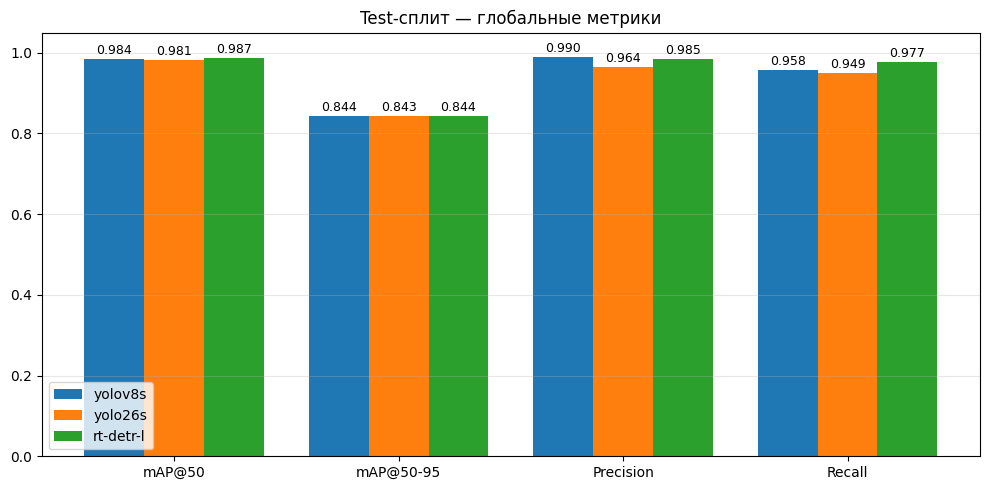

In [5]:
METRICS = ["mAP@50", "mAP@50-95", "Precision", "Recall"]
names = list(results.keys())
x = np.arange(len(METRICS))
width = 0.8 / len(names)

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(names):
    vals = [results[name][m] for m in METRICS]
    bars = ax.bar(x + i * width - 0.4 + width / 2, vals, width, label=name)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1.05)
ax.set_title("Test-сплит — глобальные метрики")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
plt.show()

## Per-class сравнение

AP@50 показывает «находит ли вообще», AP@50-95 — точность локализации.
Узкое место обычно сидит во второй метрике для редких/мелких классов.

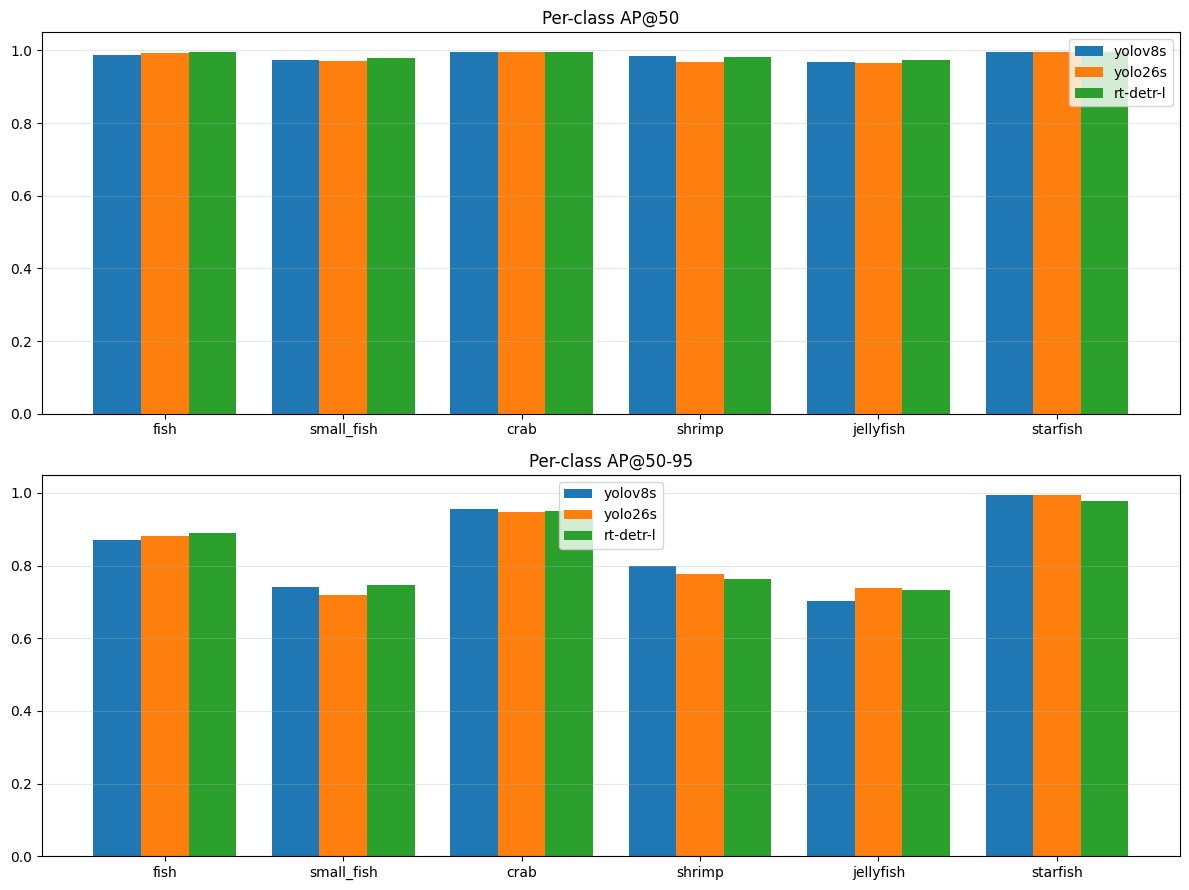

In [6]:
classes = list(next(iter(results.values()))["per_class_ap50"].keys())
x = np.arange(len(classes))
width = 0.8 / len(names)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, key, title in zip(
    axes,
    ["per_class_ap50", "per_class_ap5095"],
    ["Per-class AP@50", "Per-class AP@50-95"],
):
    for i, name in enumerate(names):
        vals = [results[name][key][c] for c in classes]
        ax.bar(x + i * width - 0.4 + width / 2, vals, width, label=name)
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend()

plt.tight_layout()
plt.show()

## Скорость инференса

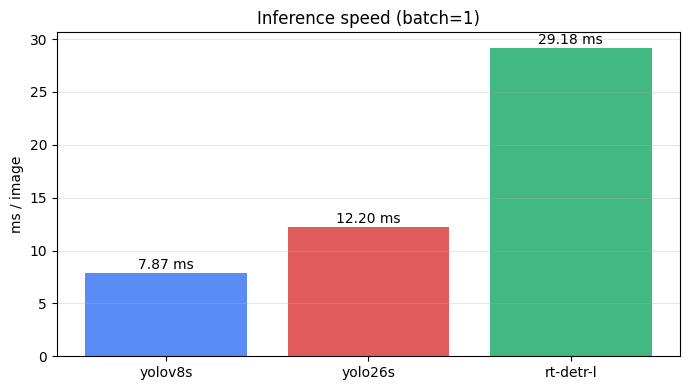

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
speeds = [results[n]["speed_ms"] for n in names]
bars = ax.bar(names, speeds, color=["#5B8CF5", "#E05C5C", "#42B883"][:len(names)])
for b, v in zip(bars, speeds):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.1, f"{v:.2f} ms",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("ms / image")
ax.set_title("Inference speed (batch=1)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()